# Exercise 2: POS tagging with BERT

**Gerasimos Chatzopoulos**  
Postgraduate student  
MSc in AI and Data Science, part-time 2025-2027  
Athens University of Economics and Business (AUEB)  
gchatzop@aueb.gr - gerasim.chatz@gmail.com

**Sevasti Yfanti**  
Postgraduate student  
MSc in AI and Data Science, part-time 2025-2027  
Athens University of Economics and Business (AUEB)  


Η βασική ιδέα είναι να χρησιμοποιήσω ένα pre trained BERT model για να προβλέψω το POS tag κάθε λέξης.

Σύντομα η διαδικασία είναι:

- χωρίζω τις προτάσεις σε tokens,
- το BERT μπορεί να χωρίσει μία λέξη σε περισσότερα WordPieces,
- αντιστοιχίζω το σωστό POS tag μόνο στο πρώτο WordPiece,
- κάνω fine-tuning το BERT στο training set,
- επιλέγω το καλύτερο setting από το development set,
- υπολογίζω τα τελικά αποτελέσματα στο test set.

Στο τέλος συγκρίνω το BERT με το baseline και με τα προηγούμενα Window MLP, BiLSTM και CNN models που έιχα.

## 1. Imports


In [1]:
%pip -q install "transformers>=4.46,<5" "datasets>=3,<5" "accelerate>=1,<2" "google-genai>=1,<2"


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 3.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.7/52.7 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 44.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 793.7/793.7 kB 21.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 19.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-adk 2.3.0 requires google-genai<3,>=2.8, but you have google-genai 1.75.0 which is incompatible.
gradio 6.19.0 requires huggingface-hub<2.0,>=1.2.0, but you have huggingface-hub 0.36.2 which is incompatible.


In [2]:
import os
import json
import random
import shutil
import urllib.request
from collections import Counter, defaultdict

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from datasets import Dataset, DatasetDict
from scipy.special import softmax
from sklearn.metrics import (
    average_precision_score,precision_recall_fscore_support,
)
from transformers import (
    AutoModelForTokenClassification,AutoTokenizer,
    DataCollatorForTokenClassification,
    Trainer,TrainingArguments,
)

SEED = 1234

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Device: cuda


## 2. Dataset

Από κάθε CoNLL U γραμμή κρατάω τη λέξη και το UPOS tag.


In [3]:
fakelos = "ud_english_ewt"
os.makedirs(fakelos, exist_ok=True)

base_url = "https://raw.githubusercontent.com/UniversalDependencies/UD_English-EWT/master"

arxeia = {
    "train": "en_ewt-ud-train.conllu",
    "dev": "en_ewt-ud-dev.conllu",
    "test": "en_ewt-ud-test.conllu",
}

for split, onoma in arxeia.items():
    topiko = os.path.join(fakelos, onoma)

    if not os.path.exists(topiko):
        urllib.request.urlretrieve(
            f"{base_url}/{onoma}",
            topiko
        )


def diavase_conllu(path):
    protaseis = []
    lexeis = []
    tags = []

    with open(path, "r", encoding="utf-8") as file:
        for grammi in file:
            grammi = grammi.strip()

            if grammi == "":
                if lexeis:
                    protaseis.append({
                        "tokens": lexeis,
                        "upos": tags
                    })
                    lexeis = []
                    tags = []
                continue

            if grammi.startswith("#"):
                continue

            merh = grammi.split("\t")
            token_id = merh[0]

            if "-" in token_id or "." in token_id:
                continue

            lexeis.append(merh[1])
            tags.append(merh[3])

    if lexeis:
        protaseis.append({
            "tokens": lexeis,
            "upos": tags
        })

    return protaseis


dedomena = {}

for split, onoma in arxeia.items():
    path = os.path.join(fakelos, onoma)
    dedomena[split] = diavase_conllu(path)

for split in ["train", "dev", "test"]:
    posa_tokens = sum(
        len(x["tokens"])
        for x in dedomena[split]
    )

    print(
        split,
        "- sentences:", len(dedomena[split]),
        "- tokens:", posa_tokens
    )


train - sentences: 12544 - tokens: 204578
dev - sentences: 2001 - tokens: 25148
test - sentences: 2077 - tokens: 25094


In [4]:
lista_tags = sorted({
    tag
    for protasi in dedomena["train"]
    for tag in protasi["upos"]
})

tag2id = {
    tag: i
    for i, tag in enumerate(lista_tags)
}

id2tag = {
    i: tag
    for tag, i in tag2id.items()
}

print("UPOS tags:", lista_tags)


UPOS tags: ['ADJ', 'ADP', 'ADV', 'AUX', 'CCONJ', 'DET', 'INTJ', 'NOUN', 'NUM', 'PART', 'PRON', 'PROPN', 'PUNCT', 'SCONJ', 'SYM', 'VERB', 'X']


## 3. Most frequent tag baseline

Για γνωστή λέξη χρησιμοποιώ το συχνότερο tag που είχε στο training set. Για unseen λέξη χρησιμοποιώ το γενικά συχνότερο trainning tag.


In [5]:
metriseis_lexewn = defaultdict(Counter)
metriseis_tags = Counter()

for protasi in dedomena["train"]:
    for lexi, tag in zip(
        protasi["tokens"],
        protasi["upos"]
    ):
        metriseis_lexewn[lexi][tag] += 1
        metriseis_tags[tag] += 1

default_tag = metriseis_tags.most_common(1)[0][0]

tag_ana_lexi = {}

for lexi, counts in metriseis_lexewn.items():
    tag_ana_lexi[lexi] = counts.most_common(1)[0][0]

print("Tag for unseen words:", default_tag)


Tag for unseen words: NOUN


## 4. Αποτελέσματα προηγούμενων models

Οι τιμές προέρχονται από τα προηγούμενα notebooks.


In [6]:
palaiotera = pd.DataFrame([
    ["Window MLP - Part 3", "train", 0.9663, 0.9118, 0.9260, 0.9608],
    ["Window MLP - Part 3", "dev",   0.8945, 0.8336, 0.8486, 0.8880],
    ["Window MLP - Part 3", "test",  0.8689, 0.8463, 0.8563, 0.8983],

    ["BiLSTM - Part 4", "train", 0.9349, 0.8767, 0.9002, 0.9396],
    ["BiLSTM - Part 4", "dev",   0.8576, 0.7966, 0.8190, 0.8574],
    ["BiLSTM - Part 4", "test",  0.8562, 0.8071, 0.8278, 0.8709],

    ["Stacked CNN - Part 5", "train", 0.944680, 0.914526, 0.927307, 0.958783],
    ["Stacked CNN - Part 5", "dev",   0.839413, 0.809407, 0.821987, 0.866715],
    ["Stacked CNN - Part 5", "test",  0.852279, 0.821422, 0.834761, 0.877031],
], columns=[
    "model","split","macro_precision",
    "macro_recall","macro_f1","macro_pr_auc",
])

display(palaiotera.round(4))


,model,split,macro_precision,macro_recall,macro_f1,macro_pr_auc
0,Window MLP - Part 3,train,0.9663,0.9118,0.9260,0.9608
1,Window MLP - Part 3,dev,0.8945,0.8336,0.8486,0.8880
2,Window MLP - Part 3,test,0.8689,0.8463,0.8563,0.8983
3,BiLSTM - Part 4,train,0.9349,0.8767,0.9002,0.9396
4,BiLSTM - Part 4,dev,0.8576,0.7966,0.8190,0.8574
5,BiLSTM - Part 4,test,0.8562,0.8071,0.8278,0.8709
6,Stacked CNN - Part 5,train,0.9447,0.9145,0.9273,0.9588
7,Stacked CNN - Part 5,dev,0.8394,0.8094,0.8220,0.8667
8,Stacked CNN - Part 5,test,0.8523,0.8214,0.8348,0.8770


## 5. Tokenization και alignment

Το BERT μπορεί να χωρίσει μία λέξη σε περισσότερα WordPieces. Το POS tag χρησιμοποιείται μόνο στο πρώτο WordPiece. Οι υπόλοιπες θέσεις παίρνουν `-100` και δεν συμμετέχουν στο loss.

Χρησιμοποιώ μέγιστο μήκος 512 WordPieces.


In [ ]:
MODEL = "bert-base-cased"
MAX_LEN = 512

tokenizer = AutoTokenizer.from_pretrained(
    MODEL,
    use_fast=True
)


def ftiaxe_split(protaseis):
    return Dataset.from_dict({
        "tokens": [
            x["tokens"]
            for x in protaseis
        ],
        "tag_ids": [
            [tag2id[tag] for tag in x["upos"]]
            for x in protaseis
        ]
    })


hf_data = DatasetDict({
    split: ftiaxe_split(dedomena[split])
    for split in ["train", "dev", "test"]
})


In [ ]:
def stoixise_tags(batch):
    tokenized = tokenizer(
        batch["tokens"],
        is_split_into_words=True,
        truncation=True,
        max_length=MAX_LEN
    )

    nea_labels = []

    for i, tags_protasis in enumerate(batch["tag_ids"]):
        word_ids = tokenized.word_ids(batch_index=i)

        labels_protasis = []
        proigoumeno_id = None

        for word_id in word_ids:
            if word_id is None:
                labels_protasis.append(-100)
            elif word_id != proigoumeno_id:
                labels_protasis.append(
                    tags_protasis[word_id]
                )
            else:
                labels_protasis.append(-100)

            proigoumeno_id = word_id

        nea_labels.append(labels_protasis)

    tokenized["labels"] = nea_labels
    return tokenized


etoima = hf_data.map(
    stoixise_tags,
    batched=True,
    remove_columns=hf_data["train"].column_names
)

collator = DataCollatorForTokenClassification(
    tokenizer=tokenizer
)

print(etoima)


Map:   0%|          | 0/12544 [00:00<?, ? examples/s]

Map:   0%|          | 0/2001 [00:00<?, ? examples/s]

Map:   0%|          | 0/2077 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['input_ids', 'token_type_ids', 'attention_mask', 'labels'],
        num_rows: 12544
    })
    dev: Dataset({
        features: ['input_ids', 'token_type_ids', 'attention_mask', 'labels'],
        num_rows: 2001
    })
    test: Dataset({
        features: ['input_ids', 'token_type_ids', 'attention_mask', 'labels'],
        num_rows: 2077
    })
})


In [ ]:
lexeis0 = hf_data["train"][0]["tokens"]

encoding0 = tokenizer(
    lexeis0,is_split_into_words=True,
    truncation=True,max_length=MAX_LEN
)

display(pd.DataFrame({
    "wordpiece": tokenizer.convert_ids_to_tokens(
        encoding0["input_ids"]
    ),
    "word_id": encoding0.word_ids(),
    "label": etoima["train"][0]["labels"]
}).head(20))


,wordpiece,word_id,label
0,[CLS],NaN,-100
1,Al,0.0,11
2,-,1.0,12
3,Z,2.0,11
4,##aman,2.0,-100
5,:,3.0,12
6,American,4.0,0
7,forces,5.0,7
8,killed,6.0,15
9,S,7.0,11


## 6. Metrics

Για κάθε split υπολογίζω macro precision, macro recall, macro F1 και macro PR-AUC.

Χρησιμοποιώ το macro F1 για την επιλογή του model, επειδή δίνει το ίδιο βάρρος σε όλα τα UPOS tags και όχι μόνο στα πιο συχνά.


In [ ]:
def ypologise_scores(logits, labels):
    pred_ids = np.argmax(logits, axis=-1)
    valid = labels != -100

    gold = labels[valid]
    pred = pred_ids[valid]
    probs = softmax(logits[valid], axis=1)

    ola_ids = np.arange(len(lista_tags))

    precision, recall, f1, support = (
        precision_recall_fscore_support(
            gold,
            pred,
            labels=ola_ids,
            zero_division=0
        )
    )

    pr_auc = []

    for tag_id in ola_ids:
        binary_gold = (gold == tag_id).astype(int)

        if binary_gold.sum() == 0:
            pr_auc.append(np.nan)
        else:
            pr_auc.append(
                average_precision_score(
                    binary_gold,
                    probs[:, tag_id]
                )
            )

    synolika = {
        "macro_precision": precision.mean(),
        "macro_recall": recall.mean(),
        "macro_f1": f1.mean(),
        "macro_pr_auc": np.nanmean(pr_auc)
    }

    ana_tag = pd.DataFrame({
        "tag": lista_tags,"precision": precision,
        "recall": recall,"f1": f1,
        "pr_auc": pr_auc,"support": support
    })

    return synolika, ana_tag, gold, pred


def metrics_for_trainer(eval_pred):
    logits, labels = eval_pred

    if isinstance(logits, tuple):
        logits = logits[0]

    synolika, _, _, _ = ypologise_scores(
        logits,
        labels
    )

    return synolika


## 7. BERT experiments

Κρατάω σταθερά το learning rate και το classifier dropout. Αλλάζω μόνο πόσα BERT blocks μένουν frozen:

- train τα τελευταία 4 blocks,
- train τα τελευταία 8 blocks,
- full fine-tuning.

Τα πρώτα blocks συνήθως κρατούν πιο γενικές πληροφορίες, ενώ τα τελευταία προσαρμόζονται περισσότερο στο συγκεκριμένο task. Με τις τρεις δοκιμές ελέγχω πόσο fine-tuning χρειάζεται το POS tagging.


In [ ]:
def ftiaxe_model(frozen_blocks):
    model = AutoModelForTokenClassification.from_pretrained(
        MODEL,
        num_labels=len(lista_tags),
        id2label=id2tag,
        label2id=tag2id,
        classifier_dropout=0.10
    )

    if frozen_blocks > 0:
        for p in model.bert.embeddings.parameters():
            p.requires_grad = False

        for block in model.bert.encoder.layer[:frozen_blocks]:
            for p in block.parameters():
                p.requires_grad = False

    return model


dokimes = [
    {"name": "last_4", "frozen_blocks": 8},
    {"name": "last_8", "frozen_blocks": 4},
    {"name": "full_bert", "frozen_blocks": 0}
]

LR = 2e-5
TRAIN_BATCH = 16
EVAL_BATCH = 32
MAX_EPOCHS = 4

BEST_DIR = "best_bert_pos"
RUNS_DIR = "bert_runs"

for folder in [BEST_DIR, RUNS_DIR]:
    if os.path.exists(folder):
        shutil.rmtree(folder)


pinakas_dokimwn = pd.DataFrame([
    {
        "setting": x["name"],
        "frozen_blocks": x["frozen_blocks"],
        "trainable_blocks": 12 - x["frozen_blocks"],
        "learning_rate": "2e-5",
        "dropout": 0.10
    }
    for x in dokimes
])

display(pinakas_dokimwn)


,setting,frozen_blocks,trainable_blocks,learning_rate,dropout
0,last_4,8,4,2e-5,0.1
1,last_8,4,8,2e-5,0.1
2,full_bert,0,12,2e-5,0.1


In [ ]:
grammes_tuning = []
grammes_epoch = []

kalitero_f1 = -1
kaliteri_dokimi = None

for dokimi in dokimes:
    print("\nRunning:", dokimi["name"])

    model = ftiaxe_model(
        dokimi["frozen_blocks"]
    )

    args = TrainingArguments(
        output_dir=os.path.join(
            RUNS_DIR,
            dokimi["name"]
        ),
        overwrite_output_dir=True,
        learning_rate=LR,
        per_device_train_batch_size=TRAIN_BATCH,
        per_device_eval_batch_size=EVAL_BATCH,
        num_train_epochs=MAX_EPOCHS,
        weight_decay=0.01,
        eval_strategy="epoch",
        save_strategy="epoch",
        logging_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="macro_f1",
        greater_is_better=True,
        save_total_limit=1,
        group_by_length=True,
        dataloader_num_workers=2,
        report_to="none",
        fp16=torch.cuda.is_available(),
        seed=SEED
    )

    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=etoima["train"],
        eval_dataset=etoima["dev"],
        data_collator=collator,
        compute_metrics=metrics_for_trainer
    )

    trainer.train()
    dev_result = trainer.evaluate()

    history = []

    for row in trainer.state.log_history:
        if "eval_macro_f1" in row:
            history.append(row)

            grammes_epoch.append({
                "setting": dokimi["name"],
                "epoch": row["epoch"],
                "dev_macro_f1": row["eval_macro_f1"],
                "dev_loss": row["eval_loss"]
            })

    best_epoch = max(
        history,
        key=lambda x: x["eval_macro_f1"]
    )["epoch"]

    grammes_tuning.append({
        "setting": dokimi["name"],
        "frozen_blocks": dokimi["frozen_blocks"],
        "learning_rate": LR,
        "best_epoch": best_epoch,
        "dev_macro_f1": dev_result["eval_macro_f1"],
        "dev_macro_pr_auc": dev_result["eval_macro_pr_auc"]
    })

    if dev_result["eval_macro_f1"] > kalitero_f1:
        kalitero_f1 = dev_result["eval_macro_f1"]
        kaliteri_dokimi = dokimi["name"]

        trainer.save_model(BEST_DIR)
        tokenizer.save_pretrained(BEST_DIR)

    del trainer
    del model

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

pinakas_epoch = (
    pd.DataFrame(grammes_epoch)
    .drop_duplicates(
        subset=["setting", "epoch"],
        keep="first"
    )
)

pinakas_tuning = pd.DataFrame(grammes_tuning)

display(pinakas_epoch.round(4))

tuning_view = (
    pinakas_tuning
    .sort_values("dev_macro_f1", ascending=False)
    .reset_index(drop=True)
)

tuning_view["learning_rate"] = tuning_view[
    "learning_rate"
].map(lambda x: f"{x:.0e}")

display(tuning_view.round(4))
print("Selected setting:", kaliteri_dokimi)



Running: last_4


Some weights of BertForTokenClassification were not initialized from the model checkpoint at bert-base-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Macro Precision,Macro Recall,Macro F1,Macro Pr Auc
1,0.407500,0.156536,0.887964,0.878783,0.882628,0.919551
2,0.112100,0.134478,0.954121,0.889383,0.898220,0.933898
3,0.085200,0.129204,0.933861,0.907343,0.910228,0.940798
4,0.072200,0.124834,0.944569,0.905502,0.911958,0.940827



Running: last_8


Some weights of BertForTokenClassification were not initialized from the model checkpoint at bert-base-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


...

Some weights of BertForTokenClassification were not initialized from the model checkpoint at bert-base-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Macro Precision,Macro Recall,Macro F1,Macro Pr Auc
1,0.273300,0.125626,0.952174,0.903724,0.909612,0.936050
2,0.060400,0.119071,0.956157,0.919125,0.927958,0.949681
3,0.032300,0.123683,0.941213,0.929368,0.932516,0.952644
4,0.020100,0.125232,0.949946,0.932412,0.938470,0.955386


,setting,epoch,dev_macro_f1,dev_loss
0,last_4,1.0,0.8826,0.1565
1,last_4,2.0,0.8982,0.1345
2,last_4,3.0,0.9102,0.1292
3,last_4,4.0,0.9120,0.1248
5,last_8,1.0,0.9088,0.1307
6,last_8,2.0,0.9198,0.1189
7,last_8,3.0,0.9354,0.1160
8,last_8,4.0,0.9326,0.1153
10,full_bert,1.0,0.9096,0.1256
11,full_bert,2.0,0.9280,0.1191


,setting,frozen_blocks,learning_rate,best_epoch,dev_macro_f1,dev_macro_pr_auc
0,full_bert,0,2e-05,4.0,0.9385,0.9554
1,last_8,4,2e-05,3.0,0.9354,0.9523
2,last_4,8,2e-05,4.0,0.9120,0.9408


Selected setting: full_bert


### Πορεία στο development set

Το παρακάτω γράφημα δείχνει το development macro F1 σε κάθε epoch για τις τρεις δοκιμές.


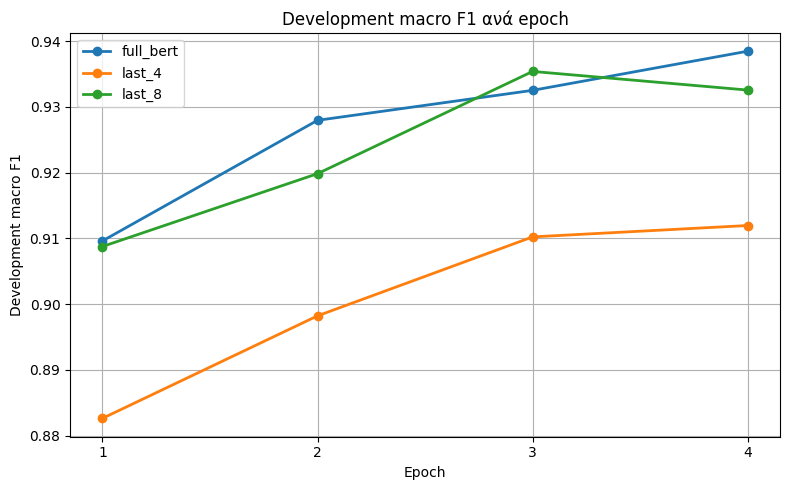

In [ ]:
plt.figure(figsize=(8, 5))

for onoma, meros in pinakas_epoch.groupby("setting"):
    meros = meros.sort_values("epoch")

    plt.plot(
        meros["epoch"],
        meros["dev_macro_f1"],
        marker="o",
        linewidth=2,
        label=onoma
    )

plt.xlabel("Epoch")
plt.ylabel("Development macro F1")
plt.title("Development macro F1 ανά epoch")
plt.xticks(sorted(pinakas_epoch["epoch"].unique()))
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Στο run που εκτελέστηκε, το full fine-tuning είχε το καλύτερο development macro F1, ενώ το `last_8` ήταν πολύ κοντά. Το `last_4` έμεινε χαμηλότερα, οπότε φαίνεται ότι το task ωφελείται όταν εκπαιδεύονται περισσότερα BERT blocks.


## 8. Τελική αξιολόγηση

Το test set δεν χρησιμοποιείται για την επιλογή παραμέτρων. Αξιολογείται μόνο αφού έχει επιλεγεί το καλύτερο setting και το καλύτερο epoch από το development set.


In [ ]:
best_model = AutoModelForTokenClassification.from_pretrained(
    BEST_DIR
)

eval_args = TrainingArguments(
    output_dir="bert_final",
    per_device_eval_batch_size=EVAL_BATCH,
    dataloader_num_workers=2,
    report_to="none"
)

final_trainer = Trainer(
    model=best_model,
    args=eval_args,
    data_collator=collator
)

bert_rows = []
pinakes_tags = {}
outputs = {}

for split in ["train", "dev", "test"]:
    out = final_trainer.predict(
        etoima[split]
    )

    outputs[split] = out

    synolika, ana_tag, gold, pred = ypologise_scores(
        out.predictions,
        out.label_ids
    )

    bert_rows.append({
        "model": "BERT - Part 6",
        "split": split,
        **synolika
    })

    pinakes_tags[split] = ana_tag

bert_results = pd.DataFrame(bert_rows)
display(bert_results.round(4))


,model,split,macro_precision,macro_recall,macro_f1,macro_pr_auc
0,BERT - Part 6,train,0.9925,0.9850,0.9885,0.9947
1,BERT - Part 6,dev,0.9499,0.9324,0.9385,0.9554
2,BERT - Part 6,test,0.9538,0.9419,0.9463,0.9655


In [ ]:
baseline_rows = []

for split in ["train", "dev", "test"]:
    gold = []
    pred = []

    for protasi in dedomena[split]:
        for lexi, tag in zip(
            protasi["tokens"],
            protasi["upos"]
        ):
            gold.append(tag2id[tag])

            predicted_tag = tag_ana_lexi.get(
                lexi,
                default_tag
            )
            pred.append(tag2id[predicted_tag])

    gold = np.array(gold)
    pred = np.array(pred)

    precision, recall, f1, _ = (
        precision_recall_fscore_support(
            gold,
            pred,
            labels=np.arange(len(lista_tags)),
            zero_division=0
        )
    )

    hard_probs = np.zeros(
        (len(pred), len(lista_tags))
    )
    hard_probs[
        np.arange(len(pred)),
        pred
    ] = 1.0

    pr_auc = []

    for tag_id in range(len(lista_tags)):
        binary_gold = (gold == tag_id).astype(int)

        pr_auc.append(
            average_precision_score(
                binary_gold,
                hard_probs[:, tag_id]
            )
        )

    baseline_rows.append({
        "model": "Most frequent tag",
        "split": split,
        "macro_precision": precision.mean(),
        "macro_recall": recall.mean(),
        "macro_f1": f1.mean(),
        "macro_pr_auc": np.mean(pr_auc)
    })

baseline_results = pd.DataFrame(baseline_rows)

ola_ta_results = pd.concat([
    baseline_results,
    palaiotera,
    bert_results
], ignore_index=True)

display(ola_ta_results.round(4))

print("Test comparison")

test_comparison = (
    ola_ta_results[
        ola_ta_results["split"] == "test"
    ]
    .sort_values("macro_f1", ascending=False)
    .reset_index(drop=True)
)

display(test_comparison.round(4))


,model,split,macro_precision,macro_recall,macro_f1,macro_pr_auc
0,Most frequent tag,train,0.9081,0.8898,0.8954,0.8173
1,Most frequent tag,dev,0.8588,0.7775,0.7993,0.6917
2,Most frequent tag,test,0.8252,0.7800,0.7924,0.6938
3,Window MLP - Part 3,train,0.9663,0.9118,0.9260,0.9608
4,Window MLP - Part 3,dev,0.8945,0.8336,0.8486,0.8880
5,Window MLP - Part 3,test,0.8689,0.8463,0.8563,0.8983
6,BiLSTM - Part 4,train,0.9349,0.8767,0.9002,0.9396
7,BiLSTM - Part 4,dev,0.8576,0.7966,0.8190,0.8574
8,BiLSTM - Part 4,test,0.8562,0.8071,0.8278,0.8709
9,Stacked CNN - Part 5,train,0.9447,0.9145,0.9273,0.9588


Test comparison


,model,split,macro_precision,macro_recall,macro_f1,macro_pr_auc
0,BERT - Part 6,test,0.9538,0.9419,0.9463,0.9655
1,Window MLP - Part 3,test,0.8689,0.8463,0.8563,0.8983
2,Stacked CNN - Part 5,test,0.8523,0.8214,0.8348,0.8770
3,BiLSTM - Part 4,test,0.8562,0.8071,0.8278,0.8709
4,Most frequent tag,test,0.8252,0.7800,0.7924,0.6938


### Σύγκριση των models στο test set


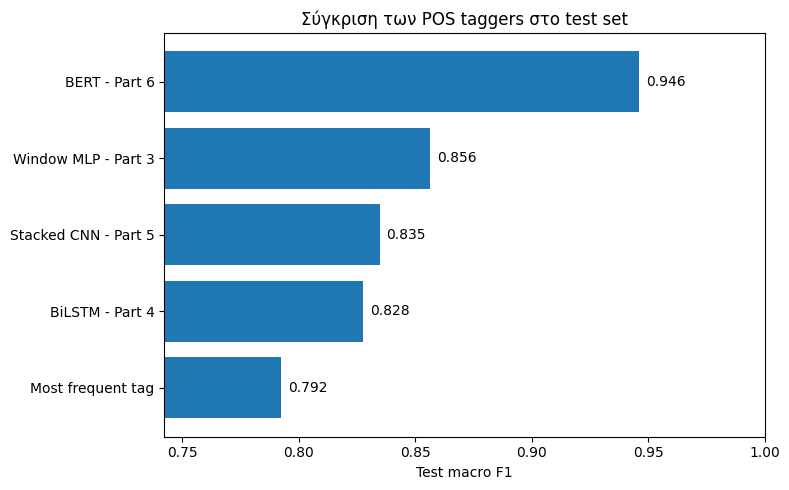

In [ ]:
plot_test = test_comparison.sort_values(
    "macro_f1",
    ascending=True
)

plt.figure(figsize=(8, 5))
plt.barh(
    plot_test["model"],
    plot_test["macro_f1"]
)

plt.xlabel("Test macro F1")
plt.title("Σύγκριση των POS taggers στο test set")

for i, value in enumerate(plot_test["macro_f1"]):
    plt.text(
        value + 0.003,
        i,
        f"{value:.3f}",
        va="center"
    )

plt.xlim(
    max(0, plot_test["macro_f1"].min() - 0.05),
    1.0
)
plt.tight_layout()
plt.show()


Στο test set το BERT είναι καθαρά πρώτο σε σχέση με το Window MLP, το Stacked CNN, το BiLSTM και το most frequent tag baseline. Επίσης, τα development και test αποτελέσματα είναι αρκετά κοντά μεταξύ τους, παρόλο που το train score είναι υψηλότερο.


## 9. Per-tag αποτελέσματα στο test set


In [ ]:
test_ana_tag = (
    pinakes_tags["test"]
    .sort_values("f1", ascending=False)
    .reset_index(drop=True)
)

display(test_ana_tag.round(4))


,tag,precision,recall,f1,pr_auc,support
0,AUX,0.9974,0.9961,0.9968,0.9993,1543
1,PART,0.9969,0.9954,0.9961,0.9990,649
2,PRON,0.9954,0.9968,0.9961,0.9994,2164
3,CCONJ,0.9986,0.9932,0.9959,0.9999,736
4,PUNCT,0.9968,0.9948,0.9958,0.9999,3096
5,DET,0.9937,0.9963,0.9950,0.9992,1897
6,ADP,0.9838,0.9881,0.9860,0.9980,2025
7,VERB,0.9820,0.9850,0.9835,0.9981,2605
8,SCONJ,0.9790,0.9714,0.9752,0.9898,384
9,NUM,0.9606,0.9889,0.9745,0.9898,542


Τα περισσότερα UPOS tags έχουν υψηλό F1. Το **X** είναι το πιο δύσκολο tag και έχει και πολύ λίγα test examples, οπότε η επίδοσής του είναι πιο ασταθής.


## 10. Ένα test example


In [ ]:
test_out = outputs["test"]
test_pred = np.argmax(
    test_out.predictions,
    axis=-1
)

sentence_id = 0

lexeis = dedomena["test"][sentence_id]["tokens"]
gold_tags = dedomena["test"][sentence_id]["upos"]

enc = tokenizer(
    lexeis,
    is_split_into_words=True,
    truncation=True,
    max_length=MAX_LEN
)

word_ids = enc.word_ids()
pred_tags = []

for word_id in range(len(lexeis)):
    position = word_ids.index(word_id)
    pred_id = test_pred[sentence_id, position]
    pred_tags.append(id2tag[int(pred_id)])

display(pd.DataFrame({
    "word": lexeis,
    "gold": gold_tags,
    "predicted": pred_tags
}))


,word,gold,predicted
0,What,PRON,PRON
1,if,SCONJ,SCONJ
2,Google,PROPN,PROPN
3,Morphed,VERB,VERB
4,Into,ADP,ADP
5,GoogleOS,PROPN,PROPN
6,?,PUNCT,PUNCT


## 11 Extra σύγκριση με LLM

Για το extra χρησιμοποιώ το Gemini 2.5 Flash-Lite ως POS tagger (το κανονικό δεν μου έτρεχε δεν ξέρω τι λάθος έκανα).

Επιλέγουμε 10 μικρές προτάσεις από το test set και δίνουμε στο μοντέλο:

- τη λίστα με τα διαθέσιμα UPOS tags,
- δύο παραδείγματα από το training set,
- τις προτάσεις που πρέπει να γίνουν tagged.

Το LLM πρέπει να επιστρέψει ένα tag για κάθε token, χωρίς να αλλάξει τη σειρά ή τον αριθμό των λέξεων.

Αυτό φυσικά είναι ενδεικτικό, επειδή χρησιμοποιείται μικρό μέρος του test set.

In [18]:
from google import genai
from google.colab import userdata
from google.genai import types

try:
    gemini_key = userdata.get("GEMINI_API_KEY")
except Exception:
    gemini_key = None

if not gemini_key:
    raise ValueError(
        "Πρόσθεσε πρώτα το GEMINI_API_KEY στα Colab Secrets."
    )

client = genai.Client(api_key=gemini_key)
LLM_MODEL = "gemini-2.5-flash-lite"

# Δύο μικρές training προτάσεις χρησιμοποιούνται ως demonstrations.
demo_ids = [
    i for i, x in enumerate(dedomena["train"])
    if 5 <= len(x["tokens"]) <= 10
][:2]

# Επιλέγουμε με σταθερό seed 10 μικρές προτάσεις από το test set.
candidate_ids = [
    i for i, x in enumerate(dedomena["test"])
    if 5 <= len(x["tokens"]) <= 12
]

bonus_random = random.Random(SEED)
bonus_ids = bonus_random.sample(candidate_ids, 10)

print("Test sentence ids:", bonus_ids)

Test sentence ids: [1327, 286, 12, 237, 1653, 120, 1862, 1924, 225, 252]


In [19]:
def ftiaxe_llm_prompt(lexeis):
    demonstrations = []

    for number, demo_id in enumerate(demo_ids, start=1):
        demo = dedomena["train"][demo_id]

        demonstrations.append(
            f"Example {number}\n"
            f"Tokens: {json.dumps(demo['tokens'])}\n"
            f"Tags: {json.dumps(demo['upos'])}"
        )

    examples_text = "\n\n".join(demonstrations)

    return f'''
You are a UPOS tagger.

Use only these tags:
{", ".join(lista_tags)}

Give exactly one tag for every input token and keep the same order.
Do not merge, remove, or add tokens.

{examples_text}

Now tag this sentence:
Tokens: {json.dumps(lexeis)}

Return only a JSON object in this form:
{{"tags": ["TAG1", "TAG2"]}}
'''


def pare_llm_tags(lexeis):
    prompt = ftiaxe_llm_prompt(lexeis)

    response = client.models.generate_content(
        model=LLM_MODEL,
        contents=prompt,
        config=types.GenerateContentConfig(
            temperature=0,
            response_mime_type="application/json"
        )
    )

    result = json.loads(response.text)
    tags = result["tags"]

    if len(tags) != len(lexeis):
        raise ValueError(
            f"Expected {len(lexeis)} tags but received {len(tags)}."
        )

    invalid_tags = [
        tag for tag in tags
        if tag not in lista_tags
    ]

    if invalid_tags:
        raise ValueError(
            f"Invalid tags returned: {invalid_tags}"
        )

    return tags

In [20]:
import time

llm_rows = []
llm_errors = []
llm_gold = []
llm_pred = []

for sentence_id in bonus_ids:
    protasi = dedomena["test"][sentence_id]

    lexeis = protasi["tokens"]
    gold_tags = protasi["upos"]
## επειδή έχω το free version google ai studio
    while True:
        try:
            predicted_tags = pare_llm_tags(lexeis)
            break

        except Exception as error:
            if ("429" in str(error) or "RESOURCE_EXHAUSTED" in str(error)
             or "503" in str(error)
             or "UNAVAILABLE" in str(error)):
                print("Temporary API error. Retry after 30 seconds.")
                time.sleep(30)
            else:
              raise error

    correct = sum(
        gold == pred
        for gold, pred in zip(gold_tags, predicted_tags)
    )

    llm_rows.append({
        "sentence_id": sentence_id,
        "sentence": " ".join(lexeis),
        "tokens": len(lexeis),
        "correct": correct,
        "token_accuracy": correct / len(lexeis)
    })

    for lexi, gold, pred in zip(
        lexeis,
        gold_tags,
        predicted_tags
    ):
        llm_gold.append(tag2id[gold])
        llm_pred.append(tag2id[pred])

        if gold != pred:
            llm_errors.append({
                "sentence_id": sentence_id,
                "word": lexi,
                "gold": gold,
                "predicted": pred
            })

    time.sleep(13)

llm_gold = np.array(llm_gold)
llm_pred = np.array(llm_pred)

_, _, llm_f1_per_tag, _ = precision_recall_fscore_support(
    llm_gold,
    llm_pred,
    labels=np.arange(len(lista_tags)),
    zero_division=0
)

llm_token_accuracy = np.mean(llm_gold == llm_pred)
llm_macro_f1 = np.mean(llm_f1_per_tag)

print("LLM model:", LLM_MODEL)
print("Test sentences:", len(bonus_ids))
print("Token accuracy:", round(llm_token_accuracy, 4))
print("Macro F1:", round(llm_macro_f1, 4))

display(
    pd.DataFrame(llm_rows).round(4)
)

print("Errors")

display(
    pd.DataFrame(llm_errors).head(30)
)

Temporary API error. Retry after 30 seconds.
Temporary API error. Retry after 30 seconds.
Temporary API error. Retry after 30 seconds.
Temporary API error. Retry after 30 seconds.
Temporary API error. Retry after 30 seconds.
LLM model: gemini-2.5-flash-lite
Test sentences: 10
Token accuracy: 0.9118
Macro F1: 0.7791


,sentence_id,sentence,tokens,correct,token_accuracy
0,1327,Unique Selling Proposition - http://www.small-...,5,2,0.4000
1,286,These guys tried the Ken Lay route .,8,8,1.0000
2,12,Click here To view it .,6,6,1.0000
3,237,"yeah , i was thinking somewhere like mcdonald ...",10,10,1.0000
4,1653,kudos to Allentown Post Office staff,6,6,1.0000
5,120,"Umir Hussain , 24 , London E14",7,6,0.8571
6,1862,They are like family .,5,5,1.0000
7,1924,Place is next to carval and walmart .,8,7,0.8750
8,225,i can think of a few things,7,7,1.0000
9,252,i got her number though .,6,5,0.8333


Errors


,sentence_id,word,gold,predicted
0,1327,Unique,ADJ,NOUN
1,1327,-,PUNCT,SYM
2,1327,http://www.small-business-software.net/unique-...,PROPN,X
3,120,E14,PROPN,NOUN
4,1924,Place,NOUN,VERB
5,252,though,ADV,SCONJ


### Αποτελεσμάτα

Το Gemini 2.5 Flash-Lite δοκιμάστηκε σε 10 προτάσεις από το test set.

Πέτυχε token accuracy 0.91 και Macro-F1 0.78. Στις περισσότερες προτάσεις έδωσε σωστά σχεδόν όλα τα POS tags, ενώ σε αρκετές περιπτώσεις είχε accuracy 1.0.

Τα λάθη που έκανε ήταν κυρίως σε πιο δύσκολες λέξεις ή σύμβολα. Για παράδειγμα, μπέρδεψε το **Unique**, ένα **URL**, το **E14** και τη λέξη **though**.

Το Macro-F1 είναι χαμηλότερο από το token accuracy, επειδή χρησιμοποιήθηκαν μόνο 10 προτάσεις και δεν υπήρχαν αρκετά παραδείγματα για όλα τα tags.

Γενικά, το LLM έδωσε αρκετά καλά αποτελέσματα κατά την γνώμη μου, αλλά η σύγκριση είναι μόνο ενδεικτική λόγω του μικρού αριθμού test προτάσεων.

## 12. Συμπέρασμα

Το καλύτερο BERT μοντέλο επιλέχθηκε με βάση τα αποτελέσματα στο development set.

Στο test set το BERT είχε καλύτερη επίδοση από το most frequent tag baseline και από τα προηγούμενα μοντέλα.

Γενικώς τα αποτελέσματα δείχνουν ότι το BERT είναι η καλύτερη μέθοδος για το συγκεκριμένο POS tagging task με διαφορα.